## Additional plots

This script contains the code to generate additional plots which were not generated in the main processor or BOB correction jupyter notebooks.

### PEC schematics

#### full curve with vibrational levels

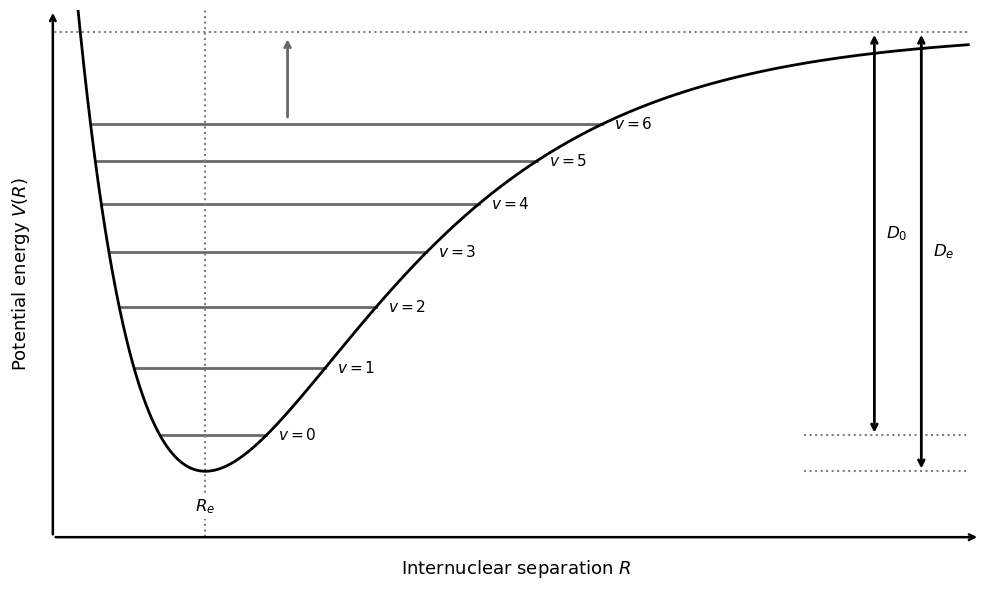

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Morse potential parameters
# ------------------------------------------------

De = 1.0
Re = 1.35
a  = 1.3          # smaller -> wider well, flatter asymptote

lam = 12          # fewer bound states -> v=6 closer to dissociation


def V(R):
    return De * (1 - np.exp(-a*(R-Re)))**2


# ------------------------------------------------
# Vibrational energies
# ------------------------------------------------

def Ev(v):

    x = (v + 0.5)/lam
    return De * (2*x - x**2)


# ------------------------------------------------
# Turning points
# ------------------------------------------------

def turning_points(E):

    s = np.sqrt(E/De)

    Rl = Re - np.log(1+s)/a
    Rr = Re - np.log(1-s)/a

    return Rl, Rr


# ------------------------------------------------
# PEC curve
# ------------------------------------------------

R = np.linspace(0.8,4.6,2000)
Vcurve = V(R)


# ------------------------------------------------
# Plot
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(10,6))

# ax.plot(R,Vcurve,color="black",lw=2)


# ------------------------------------------------
# Vibrational levels
# ------------------------------------------------

vmax = 6

for v in range(vmax+1):

    E = Ev(v)

    Rl,Rr = turning_points(E)

    ax.plot([Rl,Rr],[E,E],color="dimgray",lw=2)

    ax.text(Rr+0.05,E,f"$v={v}$",va="center",fontsize=11)


# ------------------------------------------------
# Equilibrium separation
# ------------------------------------------------

ax.axvline(Re,ls=":",color="gray")

ax.text(
    Re, -0.06, "$R_e$",
    ha="center",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="none", pad=2)
)
# ax.text(Re,-0.05,"$R_e$",ha="center",va="top",fontsize=12)


# ------------------------------------------------
# Reference lines (same width/position)
# ------------------------------------------------

x1 = 3.9
x2 = 4.6

E0 = Ev(0)

ax.plot([0,x2],[De,De],ls=":",color="grey")
ax.plot([x1,x2],[E0,E0],ls=":",color="grey")
ax.plot([x1,x2],[0,0],ls=":",color="grey")


# ------------------------------------------------
# Dissociation energy arrow
# ------------------------------------------------

ax.annotate("",
            xy=(4.4,De),
            xytext=(4.4,0),
            arrowprops=dict(arrowstyle="<->",lw=2))

ax.text(4.45,De/2,"$D_e$",va="center",fontsize=12)


# ------------------------------------------------
# Binding energy arrow
# ------------------------------------------------

ax.annotate("",
            xy=(4.2,De),
            xytext=(4.2,E0),
            arrowprops=dict(arrowstyle="<->",lw=2))

ax.text(4.25,(De+E0)/2,"$D_0$",va="center",fontsize=12)



# 
# Higher v states arrow
#

ax.annotate(
    "",
    xy=(1.7, 0.99),
    xytext=(1.7, Ev(6)+0.01),
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=2)
)


ax.plot(R,Vcurve,color="black",lw=2)

# ------------------------------------------------
# Axes
# ------------------------------------------------

ax.set_xlabel("Internuclear separation $R$",fontsize=13)
ax.set_ylabel("Potential energy $V(R)$",fontsize=13)

ax.set_xlim(0.7,4.65)
ax.set_ylim(-0.15,1.05)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# x-axis arrow
ax.annotate(
    "",
    xy=(xmax, ymin),
    xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

# y-axis arrow
ax.annotate(
    "",
    xy=(xmin, ymax),
    xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle="->", lw=1.8)
)

ax.set_xlabel("Internuclear separation $R$", labelpad=15)
ax.set_ylabel("Potential energy $V(R)$", labelpad=15)
plt.tight_layout()

plt.show()

**Figure X.** Schematic potential energy curve for a diatomic molecule showing vibrational energy levels $v=0$–$6$. The equilibrium bond length $R_e$, dissociation energy $D_e$, and zero-point dissociation energy $D_0$ are indicated. The spacing between vibrational levels decreases with increasing $v$ due to anharmonicity. Only a subset of bound vibrational states is shown; additional levels approach the dissociation limit.

#### Zoomed into rovibrational levels

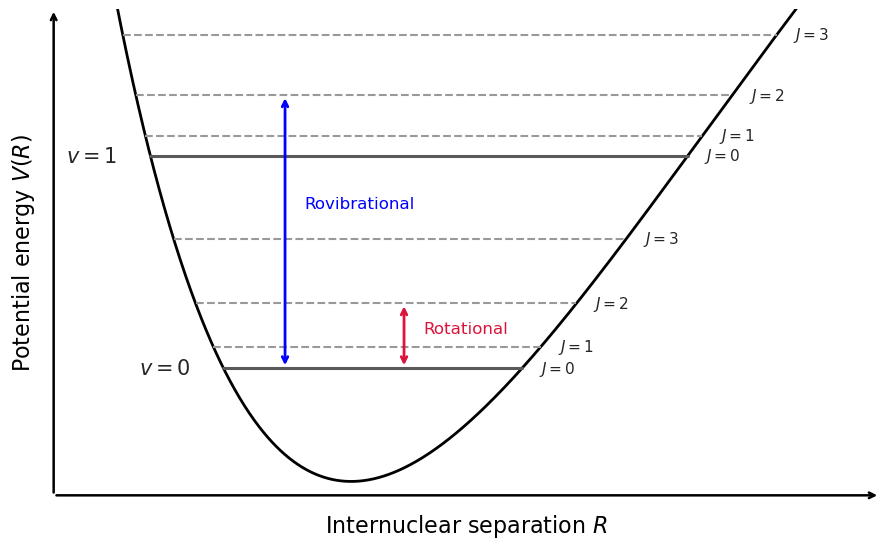

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Same PEC as first figure
# ============================================================

De = 1.0
Re = 1.35
a  = 1.3
lam = 12

def V(R):
    return De * (1 - np.exp(-a * (R - Re)))**2

def Ev(v):
    x = (v + 0.5) / lam
    return De * (2*x - x**2)

def turning_points(E):
    s = np.sqrt(E / De)
    Rl = Re - np.log(1 + s) / a
    Rr = Re - np.log(1 - s) / a
    return Rl, Rr

# ============================================================
# Rotational structure
# ============================================================

# Reduced substantially so rotational spacings are smaller
Be = 0.008
alpha_e = 0.0005

def Bv(v):
    return Be - alpha_e * (v + 0.5)

def E_vJ(v, J):
    return Ev(v) + Bv(v) * J * (J + 1)

# ============================================================
# Plot
# ============================================================

R = np.linspace(0.9, 2.35, 2000)
Vcurve = V(R)

fig, ax = plt.subplots(figsize=(9, 5.6))

# PEC
ax.plot(R, Vcurve, color="black", lw=2)

# ============================================================
# Draw vibrational and rotational levels
# ============================================================

v_values = [0, 1]
Jmax = 3

# First draw darker vibrational baselines (J=0)
for v in v_values:
    E = E_vJ(v, 0)
    Rl, Rr = turning_points(E)
    ax.plot([Rl, Rr], [E, E], color="0.35", lw=2.2, solid_capstyle="round")

# Then draw lighter rotational excited levels (J > 0)
for v in v_values:
    for J in range(1, Jmax + 1):
        E = E_vJ(v, J)
        Rl, Rr = turning_points(E)
        ax.plot([Rl, Rr], [E, E], color="0.60", lw=1.5, ls="--", solid_capstyle="round")

# ============================================================
# Labels
# ============================================================

# Vibrational labels on left, darker/bolder
for v in v_values:
    E = E_vJ(v, 0)
    Rl, Rr = turning_points(E)
    ax.text(Rl - 0.05, E, fr"$v={v}$", ha="right", va="center",
            fontsize=15, fontweight="bold", color="0.15")

# Rotational labels on right
for v in v_values:
    for J in range(Jmax + 1):
        E = E_vJ(v, J)
        Rl, Rr = turning_points(E)
        ax.text(Rr + 0.025, E, fr"$J={J}$", ha="left", va="center",
                fontsize=11, color="0.15")

# ============================================================
# Example transitions
# ============================================================

# Rotational: v=0, J=0 -> 2
E_low_rot = E_vJ(0, 0)
E_up_rot  = E_vJ(0, 2)

x_rot = 1.43
ax.annotate(
    "",
    xy=(x_rot, E_up_rot),
    xytext=(x_rot, E_low_rot),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=2)
)
ax.text(
    x_rot + 0.03,
    0.5 * (E_low_rot + E_up_rot)+0.005,
    "Rotational",
    color="crimson",
    fontsize=12,
    va="center",
    ha="left"
)

# Rovibrational: v=0, J=0 -> v=1, J=1
E_low_rv = E_vJ(0, 0)
E_up_rv  = E_vJ(1, 2)

x_rv = 1.25
ax.annotate(
    "",
    xy=(x_rv, E_up_rv),
    xytext=(x_rv, E_low_rv),
    arrowprops=dict(arrowstyle="<->", color="blue", lw=2)
)
ax.text(
    x_rv + 0.03,
    0.5 * (E_low_rv + E_up_rv)+0.02,
    "Rovibrational",
    color="blue",
    fontsize=12,
    va="center",
    ha="left"
)

# ============================================================
# Axes styling
# ============================================================

ax.set_xlim(0.9, 2.15)
ax.set_ylim(-0.01, 0.34)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# x-axis arrow
ax.annotate(
    "",
    xy=(xmax, ymin),
    xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle="->", lw=1.8, color="black")
)

# y-axis arrow
ax.annotate(
    "",
    xy=(xmin, ymax),
    xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle="->", lw=1.8, color="black")
)

ax.set_xlabel("Internuclear separation $R$", fontsize=16, labelpad=12)
ax.set_ylabel("Potential energy $V(R)$", fontsize=16, labelpad=12)

plt.tight_layout()
plt.show()

**Figure Y.** Expanded view of the lower region of the potential energy curve illustrating rotational substructure within the $v=0$ and $v=1$ vibrational states. Rotational levels are labelled by the quantum number $J$. Example rotational ($\Delta v=0$) and rovibrational ($\Delta v=1$) transitions are indicated.

### Le Roy PEC

See BOB correction script

### Le Roy QMF

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ------------------------------------------------
# Li-Le Roy analytical QMF data
# units: bohr, au
# ------------------------------------------------

data = np.array([
    [0.800000,  -5.04227790],
    [0.900000,  -3.28178363],
    [1.000000,  -2.66140290],
    [1.100000,  -2.33016744],
    [1.200000,  -2.10718770],
    [1.300000,  -1.93870903],
    [1.400000,  -1.80192284],
    [1.500000,  -1.68464819],
    [1.600000,  -1.57938241],
    [1.620000,  -1.55929771],
    [1.640000,  -1.53945605],
    [1.660000,  -1.51982789],
    [1.680000,  -1.50038560],
    [1.700000,  -1.48110350],
    [1.720000,  -1.46195760],
    [1.740000,  -1.44292561],
    [1.760000,  -1.42398681],
    [1.780000,  -1.40512191],
    [1.800000,  -1.38631312],
    [1.820000,  -1.36754397],
    [1.840000,  -1.34879927],
    [1.860000,  -1.33006516],
    [1.880000,  -1.31132174],
    [1.900000,  -1.29257189],
    [1.920000,  -1.27379808],
    [1.940000,  -1.25499107],
    [1.960000,  -1.23614270],
    [1.980000,  -1.21724585],
    [2.000000,  -1.19829444],
    [2.020000,  -1.17928343],
    [2.040000,  -1.16020837],
    [2.060000,  -1.14106687],
    [2.074320,  -1.12731930],
    [2.080000,  -1.12185647],
    [2.100000,  -1.10257607],
    [2.120000,  -1.08322544],
    [2.140000,  -1.06380532],
    [2.160000,  -1.04431742],
    [2.180000,  -1.02476428],
    [2.200000,  -1.00514939],
    [2.220000,  -0.98547718],
    [2.240000,  -0.96575290],
    [2.260000,  -0.94598274],
    [2.280000,  -0.92617373],
    [2.300000,  -0.90633344],
    [2.320000,  -0.88647179],
    [2.340000,  -0.86659755],
    [2.360000,  -0.84672105],
    [2.380000,  -0.82685355],
    [2.400000,  -0.80700703],
    [2.420000,  -0.78719428],
    [2.440000,  -0.76742879],
    [2.460000,  -0.74772476],
    [2.480000,  -0.72809659],
    [2.500000,  -0.70856180],
    [2.520000,  -0.68913447],
    [2.540000,  -0.66983214],
    [2.560000,  -0.65067215],
    [2.580000,  -0.63167243],
    [2.600000,  -0.61285155],
    [2.700000,  -0.52210360],
    [2.800000,  -0.43882515],
    [2.900000,  -0.36560900],
    [3.000000,  -0.30498097],
    [3.100000,  -0.25901974],
    [3.200000,  -0.22883394],
    [3.300000,  -0.21381026],
    [3.400000,  -0.21119132],
    [3.500000,  -0.21618769],
    [3.600000,  -0.22306935],
    [3.700000,  -0.22695679],
    [3.800000,  -0.22499292],
    [3.900000,  -0.21658807],
    [4.000000,  -0.20267997],
    [4.100000,  -0.18499796],
    [4.200000,  -0.16521555],
    [4.300000,  -0.14474736],
    [4.400000,  -0.12465870],
    [4.500000,  -0.10564220],
    [4.600000,  -0.08812331],
    [4.700000,  -0.07226102],
    [4.800000,  -0.05815612],
    [4.900000,  -0.04577389],
    [5.000000,  -0.03502941],
    [5.100000,  -0.02580237],
    [5.200000,  -0.01795970],
    [5.300000,  -0.01136635],
    [5.400000,  -0.00588433],
    [5.500000,  -0.00140919],
    [5.600000,   0.00224394],
    [5.700000,   0.00515564],
    [5.800000,   0.00742320],
    [5.900000,   0.00916097],
    [6.000000,   0.01042108],
    [6.100000,   0.01133187],
    [6.200000,   0.01192593],
    [6.300000,   0.01226610],
    [6.400000,   0.01239650],
    [6.500000,   0.01235899],
    [6.600000,   0.01218837],
    [6.700000,   0.01189679],
    [6.800000,   0.01154506],
    [6.900000,   0.01113796],
    [7.000000,   0.01069248],
    [7.100000,   0.01022410],
    [7.200000,   0.00974025],
    [7.300000,   0.00924976],
    [7.400000,   0.00874702],
    [7.500000,   0.00826777],
    [7.600000,   0.00782426],
    [7.700000,   0.00737341],
    [7.800000,   0.00694138],
    [7.900000,   0.00652142],
    [8.000000,   0.00612138],
    [8.100000,   0.00573688],
    [8.200000,   0.00537002],
    [8.300000,   0.00502142],
    [8.400000,   0.00468819],
    [8.500000,   0.00437296],
    [8.600000,   0.00407385],
    [8.700000,   0.00379034],
    [8.800000,   0.00352186],
    [8.900000,   0.00326815],
    [9.000000,   0.00302839],
    [9.100000,   0.00280240],
    [9.200000,   0.00258985],
    [9.300000,   0.00239048],
    [9.400000,   0.00220411],
    [9.500000,   0.00203082],
    [9.600000,   0.00186568],
    [9.700000,   0.00171766],
    [9.800000,   0.00158184],
    [9.900000,   0.00145763],
    [10.000000,  0.00134455],
    [10.100000,  0.00124204],
    [10.200000,  0.00114949],
    [10.300000,  0.00106626],
    [10.400000,  0.00099163],
    [10.500000,  0.00092487],
    [10.600000,  0.00086521],
    [10.700000,  0.00081188],
    [10.800000,  0.00076419],
    [10.900000,  0.00072144],
    [11.000000,  0.00068298],
    [11.100000,  0.00064820],
    [11.200000,  0.00061663],
    [11.300000,  0.00058773],
    [11.400000,  0.00056113],
    [11.500000,  0.00053649],
    [11.600000,  0.00051346],
    [11.700000,  0.00049185],
    [11.800000,  0.00047141],
    [11.900000,  0.00045200],
    [12.000000,  0.00043348],
    [12.100000,  0.00041576],
])

r_bohr = data[:, 0]
q_au   = data[:, 1]

BOHR_TO_ANG = 0.529177210903

def bohr_to_ang(x):
    return x * BOHR_TO_ANG

def ang_to_bohr(x):
    return x / BOHR_TO_ANG

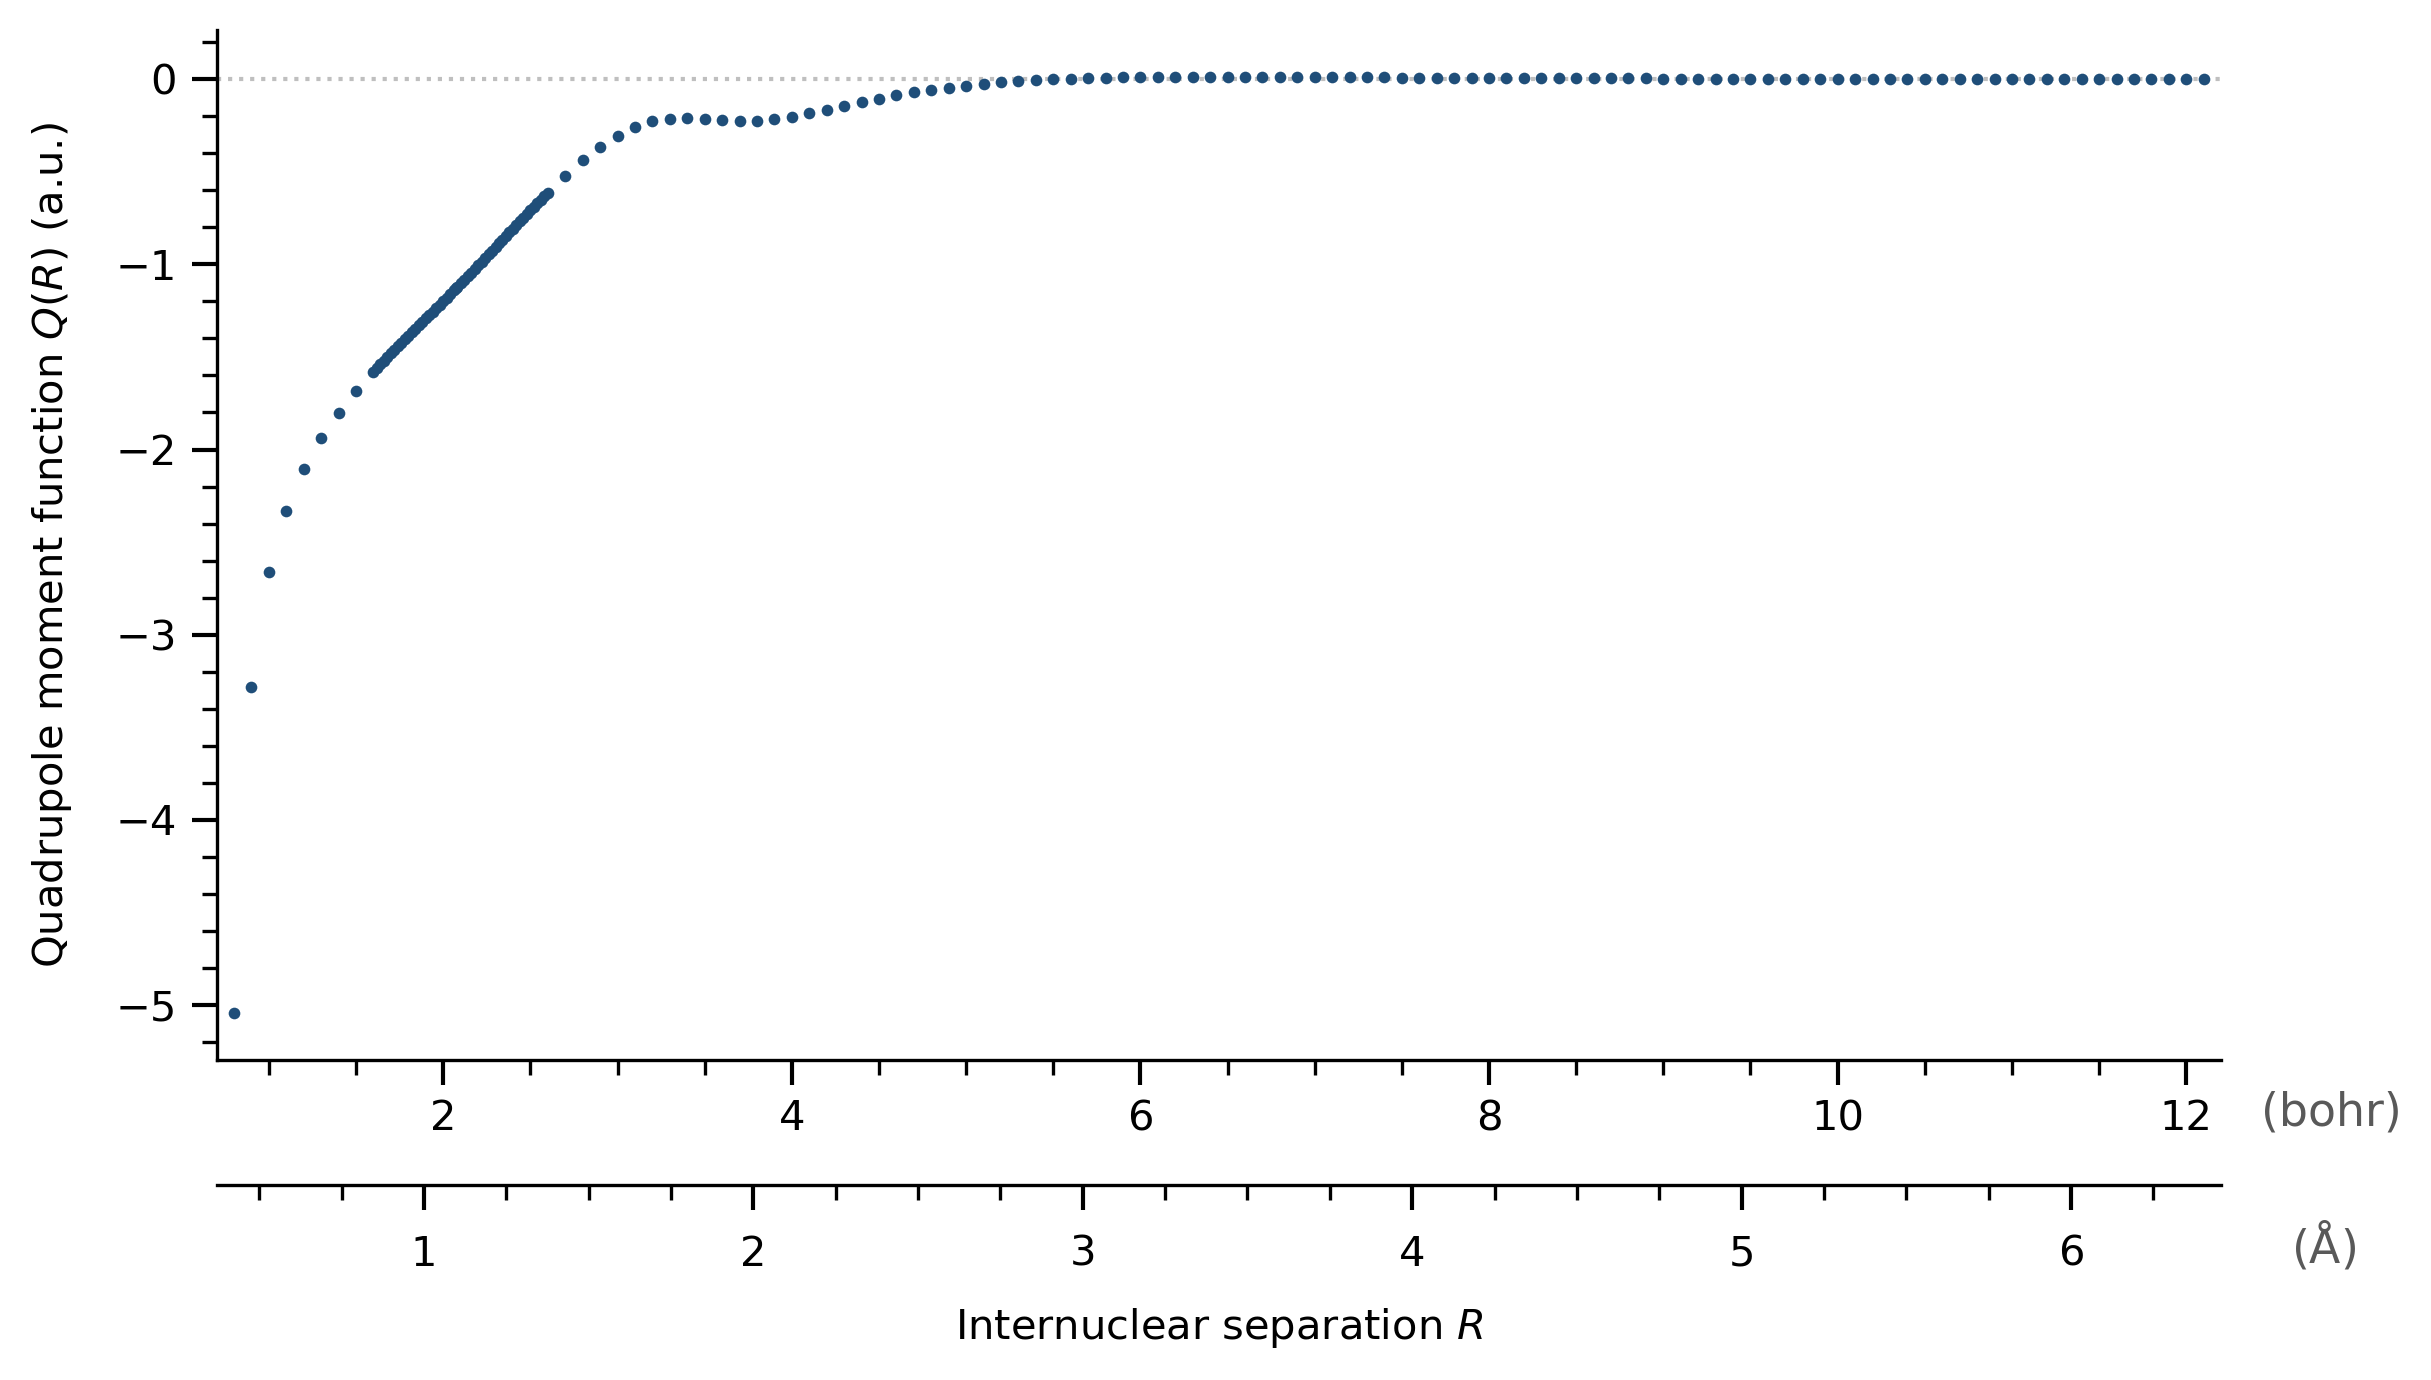

In [4]:
# ------------------------------------------------
# Plot
# ------------------------------------------------

from matplotlib.ticker import MultipleLocator, AutoMinorLocator

BOHR_TO_ANG = 0.529177210903

def bohr_to_ang(x):
    return x * BOHR_TO_ANG

def ang_to_bohr(x):
    return x / BOHR_TO_ANG

fig, ax = plt.subplots(figsize=(8.2, 4.7), dpi=300)

# Main curve: markers only
ax.plot(
    r_bohr,
    q_au,
    linestyle="None",
    marker="o",
    markersize=2.8,
    markerfacecolor="#1f4e79",
    markeredgecolor="#1f4e79",
    markeredgewidth=0.0,
    zorder=3,
)

# Optional faint zero line
ax.axhline(0.0, color="0.75", ls=":", lw=1.0, zorder=1)

# Axis labels
ax.set_ylabel(r"Quadrupole moment function $Q(R)$ (a.u.)", labelpad=10)
ax.set_xlabel(r"Internuclear separation $R$", labelpad=40)

# Limits
ax.set_xlim(r_bohr.min() - 0.1, r_bohr.max() + 0.1)

# Ticks for main axis (bohr)
ax.xaxis.set_major_locator(MultipleLocator(2.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Secondary x-axis below, in Å
secax = ax.secondary_xaxis("bottom", functions=(bohr_to_ang, ang_to_bohr))
secax.spines["bottom"].set_position(("outward", 30))

# No separate xlabel here
secax.set_xlabel("")

# Ticks for lower axis (Å)
secax.xaxis.set_major_locator(MultipleLocator(1.0))
secax.xaxis.set_minor_locator(AutoMinorLocator(4))

# Spine styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
secax.spines["top"].set_visible(False)

# Tick styling
ax.tick_params(axis="both", which="major", direction="out", length=6, width=1)
ax.tick_params(axis="both", which="minor", direction="out", length=3.5, width=0.8)
secax.tick_params(axis="x", which="major", direction="out", length=6, width=1, pad=6)
secax.tick_params(axis="x", which="minor", direction="out", length=3.5, width=0.8)

# Unit labels at right-hand side of each scale
ax.text(
    1.02, -.03, "(bohr)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=11, color="0.35"
)

ax.text(
    1.035, -0.155, r"($\mathrm{\AA}$)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=11, color="0.35"
)

plt.tight_layout()
plt.show()

**Figure X.** Analytical Li–Le Roy quadrupole moment function $Q(R)$ (in atomic units, a.u. = $e a_0^2$) as a function of internuclear separation $R$. The function is sampled at $0.1$ bohr, with a finer spacing of $0.02$ bohr between $1.6$ and $2.6$ bohr.

### HITRAN line lists

In [5]:
import pandas as pd
import re


PAR_FILE_14N2    = "HITRAN/linelists/14N2_Q.par"
PAR_FILE_1415N    = "HITRAN/linelists/14N15N_Q.par"

# BANDS_14N2 = [
#     (0, 0,    0.0,   600.0),
#     (1, 0, 1500.0,  3200.0),
#     (2, 0, 3600.0,  5600.0),
#     (3, 0, 6000.0,  7850.0),
#     (4, 0, 8300.0,  9800.0),
# ]

# def vv_from_nu(nu):
#     for vu, vl, lo, hi in BANDS_14N2:
#         if lo <= nu <= hi:
#             return vu, vl
#     return None, None



def parse_hitran(par_path):
    """
    Returns dataframe with:
      v_u, v_l, J_u, J_l, nu_hitran, I_hitran
    J is decoded from the local label like "S  3q" in the local quantum fields.
    v_u,v_l assigned by band windows (not decoded from HITRAN's global strings).
    """
    rows = []
    with open(par_path, "r") as f:
        for line in f:
            if not line.strip():
                continue

            nu = float(line[3:15])
            I  = float(line[15:25])  # sw

            # local quantum strings (HITRAN2004 layout)
            local_u = line[97:112].strip()
            local_l = line[112:127].strip()

            # Most N2 Q lines have branch label in local_l (e.g. "S  0q")
            m = re.match(r"^([OPQRS])\s*(\d+)", local_l)
            if not m:
                continue

            br = m.group(1)
            Jl = int(m.group(2))
            dJ = {"S": 2, "R": 1, "Q": 0, "P": -1, "O": -2}.get(br, None)
            if dJ is None:
                continue
            Ju = Jl + dJ

            # vu, vl = vv_from_nu(nu)
            # if vu is None:
            #     continue  # ignore lines outside your generous band windows

            rows.append((Ju, Jl, nu, I))

    return pd.DataFrame(rows, columns=["J_u", "J_l", "nu_hitran", "I_hitran"])

df_hitran_14N2 = parse_hitran(PAR_FILE_14N2)
df_hitran_14N15N = parse_hitran(PAR_FILE_1415N)


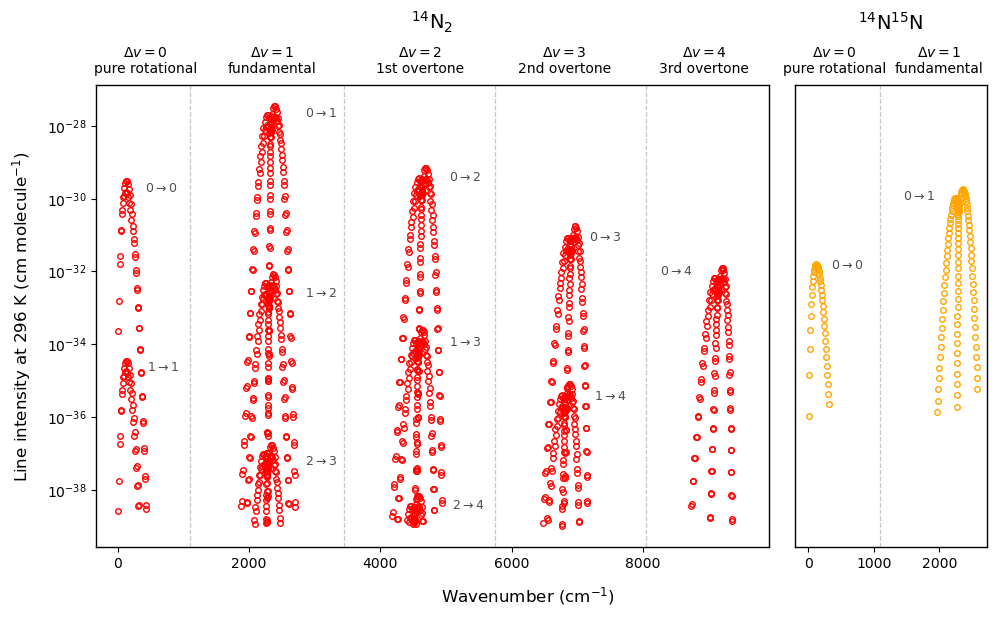

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# ---------------------------------
# Data ranges
# ---------------------------------
x1_data_max = df_hitran_14N2["nu_hitran"].max()
x2_data_max = df_hitran_14N15N["nu_hitran"].max()

# Add a little space left of zero so markers are not cut off
left_pad1 = 0.035 * x1_data_max
left_pad2 = 0.08 * x2_data_max

x1_min = -left_pad1
x2_min = -left_pad2

# Add a little padding on the right too
pad_frac = 0.06
x1_max = x1_data_max + pad_frac * x1_data_max
x2_max = x2_data_max + pad_frac * x2_data_max

range1 = x1_max - x1_min
range2 = x2_max - x2_min

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(11.5, 6),
    sharey=True,
    gridspec_kw={
        "wspace": 0.06,
        "width_ratios": [range1, range2]
    }
)

# ---------------------------------
# Left panel: 14N2
# ---------------------------------
ax1.plot(
    df_hitran_14N2["nu_hitran"],
    df_hitran_14N2["I_hitran"],
    linestyle="none",
    marker="o",
    markersize=4,
    markerfacecolor="none",
    markeredgecolor="red"
)

ax1.set_yscale("log")
ax1.set_xlim(x1_min, x1_max)
ax1.set_ylabel(r"Line intensity at 296 K (cm molecule$^{-1}$)", labelpad=10, fontsize=12)
ax1.set_title(r"$^{14}$N$_2$", pad=40, fontsize=14)

# ---------------------------------
# Right panel: 14N15N
# ---------------------------------
ax2.plot(
    df_hitran_14N15N["nu_hitran"],
    df_hitran_14N15N["I_hitran"],
    linestyle="none",
    marker="o",
    markersize=4,
    markerfacecolor="none",
    markeredgecolor="orange"
)

ax2.set_yscale("log")
ax2.set_xlim(x2_min, x2_max)
ax2.set_title(r"$^{14}$N$^{15}$N", pad=40, fontsize=14)

# ---------------------------------
# Styling
# ---------------------------------
# Keep all spines so the separator is just the natural axis borders
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

# No duplicate y-axis labels/ticks on right
ax2.tick_params(axis="y", labelleft=False, left=False)

# Force a tick at 0 on both x-axes
ticks1 = [0, 2000, 4000, 6000, 8000]
ticks1 = [t for t in ticks1 if x1_min <= t <= x1_max]
ax1.xaxis.set_major_locator(FixedLocator(ticks1))

ticks2 = [0, 1000, 2000]
ticks2 = [t for t in ticks2 if x2_min <= t <= x2_max]
ax2.xaxis.set_major_locator(FixedLocator(ticks2))

# Shared labels
fig.supxlabel(r"Wavenumber (cm$^{-1}$)")
# fig.suptitle(r"Quadrupole spectra", y=0.98)


# ---------------------------------
# Band dividers and labels
# ---------------------------------

divider_kw = dict(color="0.78", lw=0.9, ls="--", zorder=0)

# 14N2 dividers
for x in [1100, 3450, 5750, 8050]:
    ax1.axvline(x, **divider_kw)

# 14N15N divider
ax2.axvline(1100, **divider_kw)

# Top labels
ax1.text(425, 1.02, r"$\Delta v = 0$" "\n" r"pure rotational",
         transform=ax1.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax1.text(2350, 1.02, r"$\Delta v = 1$" "\n" r"fundamental",
         transform=ax1.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax1.text(4600, 1.02, r"$\Delta v = 2$" "\n" r"1st overtone",
         transform=ax1.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax1.text(6800, 1.02, r"$\Delta v = 3$" "\n" r"2nd overtone",
         transform=ax1.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax1.text(8930, 1.02, r"$\Delta v = 4$" "\n" r"3rd overtone",
         transform=ax1.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax2.text(400, 1.02, r"$\Delta v = 0$ " "\n" r"pure rotational",
         transform=ax2.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

ax2.text(2000, 1.02, r"$\Delta v = 1$" "\n" r"fundamental",
         transform=ax2.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=10)

# ---------------------------------
# Compact sub-band labels
# ---------------------------------

subkw = dict(color="0.30", fontsize=9)

# 14N2: Δv = 0 (place to right of the cluster)
ax1.text(420,  1.5e-30, r"$0 \rightarrow 0$", ha="left", **subkw)
ax1.text(450,  1.8e-35, r"$1 \rightarrow 1$", ha="left", **subkw)

# 14N2: Δv = 1
ax1.text(2860, 1.8e-28, r"$0 \rightarrow 1$", ha="left", **subkw)
ax1.text(2860, 2.0e-33, r"$1 \rightarrow 2$", ha="left", **subkw)
ax1.text(2860, 5.0e-38, r"$2 \rightarrow 3$", ha="left", **subkw)

# 14N2: Δv = 2
ax1.text(5050, 3.0e-30, r"$0 \rightarrow 2$", ha="left", **subkw)
ax1.text(5050, 9.0e-35, r"$1 \rightarrow 3$", ha="left", **subkw)
ax1.text(5100, 3.0e-39, r"$2 \rightarrow 4$", ha="left", **subkw)

# 14N2: Δv = 3
ax1.text(7180, 7.0e-32, r"$0 \rightarrow 3$", ha="left", **subkw)
ax1.text(7250, 3.0e-36, r"$1 \rightarrow 4$", ha="left", **subkw)

# 14N2: Δv = 4 (place label to the left, since little room on the right)
ax1.text(8750, 8.0e-33, r"$0 \rightarrow 4$", ha="right", **subkw)

# 14N15N: only visible cold bands
ax2.text(350,  1.2e-32, r"$0 \rightarrow 0$", ha="left", **subkw)
ax2.text(1450, 9.0e-31, r"$0 \rightarrow 1$", ha="left", **subkw)


# plt.tight_layout()
plt.show()

HITRAN line intensities at 296~K for $^{14}\mathrm{N}_2$ (left) and $^{14}\mathrm{N}^{15}\mathrm{N}$ (right) as a function of wavenumber. The horizontal scale is matched between panels, with widths proportional to the spectral range of each isotopologue. Band groupings are separated by dashed lines and labelled by $\Delta v$, with individual vibrational transitions ($v'' \rightarrow v'$) indicated within each band.

HITRAN line intensities at 296~K for $^{14}\mathrm{N}_2$ (left) and $^{14}\mathrm{N}^{15}\mathrm{N}$ (right) as a function of wavenumber. Band groupings are indicated by $\Delta v$, showing the progression from pure rotational to fundamental and overtone transitions. Individual vibrational transitions ($v'' \rightarrow v'$) are labelled within each band; hot bands originating from excited vibrational states are visible for $^{14}\mathrm{N}_2$, while only fundamental transitions are present for $^{14}\mathrm{N}^{15}\mathrm{N}$ in the plotted range

### CIA

The plotted CIA datasets are used here to indicate the spectral regions in which collision-induced absorption may contribute a broad continuum overlapping the N
2
2
	​

 quadrupole bands. Since the available CIA data are near room temperature, and CIA and quadrupole absorption are not directly comparable in their native units, these plots are intended as qualitative guidance only.

Selected temperatures by species and spectral region:

N2-Ar:
  0.0–400.0 cm^-1 : 300.0 K
  2100.0–2600.0 cm^-1 : 300.0 K

N2-CH4:
  0.0–800.0 cm^-1 : 300.0 K

N2-H2:
  0.0–1886.0 cm^-1 : 309.7 K
  3900.0–5100.0 cm^-1 : 296.0 K

N2-H2O:
  1930.0–2830.0 cm^-1 : 300.0 K

N2-He:
  1.0–1000.0 cm^-1 : 300.0 K

N2-N2:
  0.0–550.0 cm^-1 : 300.0 K
  1850.0–3000.1 cm^-1 : 300.9 K
  4300.0–5000.0 cm^-1 : 298.0 K


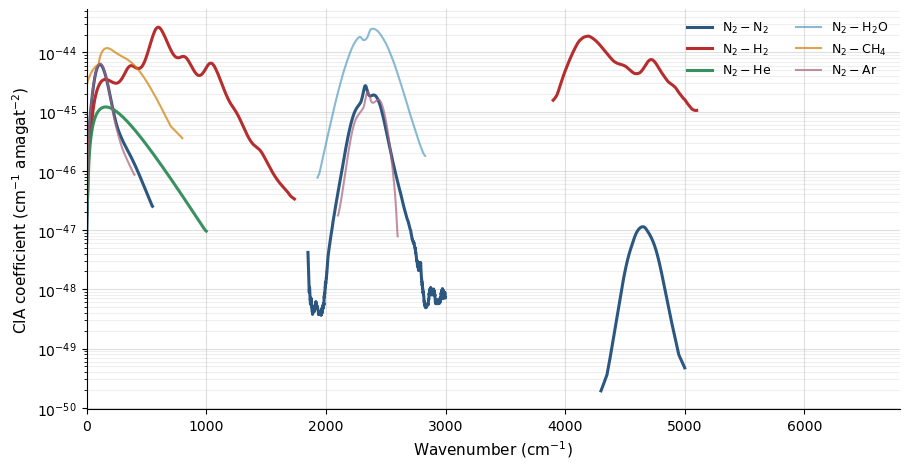

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def read_hitran_cia_blocks_nearest_temp_per_region(filepath, target_temp=296.0):
    """
    Read a HITRAN .cia file and, for each spectral region (nu_min, nu_max, npts),
    keep the block at the temperature nearest to target_temp.

    Assumed header format:
        pair, nu_min, nu_max, npts, T, ...
    followed by npts rows of:
        nu, cia
    """
    spectra = []

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        parts = lines[i].split()

        if len(parts) >= 5 and not parts[0][0].isdigit():
            try:
                pair = parts[0]
                nu_min = float(parts[1])
                nu_max = float(parts[2])
                npts = int(parts[3])
                temp = float(parts[4])
            except ValueError:
                i += 1
                continue

            wn = []
            cia = []
            j = i + 1
            count = 0

            while j < len(lines) and count < npts:
                row = lines[j].split()
                if len(row) >= 2:
                    try:
                        wn.append(float(row[0]))
                        cia.append(float(row[1]))
                        count += 1
                    except ValueError:
                        pass
                j += 1

            if wn:
                spectra.append({
                    "pair": pair,
                    "nu_min": nu_min,
                    "nu_max": nu_max,
                    "npts": npts,
                    "temp": temp,
                    "df": pd.DataFrame({"nu": wn, "cia": cia}).sort_values("nu").reset_index(drop=True)
                })

            i = j
        else:
            i += 1

    if not spectra:
        return [], []

    # Group by spectral region and choose nearest T within each region
    region_groups = {}
    for spec in spectra:
        key = (spec["nu_min"], spec["nu_max"], spec["npts"])
        region_groups.setdefault(key, []).append(spec)

    selected_blocks = []
    selected_info = []

    for key, group in region_groups.items():
        best = min(group, key=lambda s: abs(s["temp"] - target_temp))
        selected_blocks.append(best["df"])
        selected_info.append({
            "pair": best["pair"],
            "nu_min": best["nu_min"],
            "nu_max": best["nu_max"],
            "npts": best["npts"],
            "temp": best["temp"]
        })

    # Sort blocks by spectral position
    selected_pairs = sorted(
        zip(selected_blocks, selected_info),
        key=lambda x: x[1]["nu_min"]
    )
    selected_blocks = [x[0] for x in selected_pairs]
    selected_info = [x[1] for x in selected_pairs]

    return selected_blocks, selected_info


def smooth_log_cia(block, window=31):
    """
    Smooth CIA values in log10-space using a centred rolling mean.
    """
    block = block.copy()

    positive = block["cia"] > 0
    block = block.loc[positive].copy()

    if len(block) < 5:
        return block

    logcia = np.log10(block["cia"].values)

    logcia_smooth = (
        pd.Series(logcia)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

    block["cia_smooth"] = 10**logcia_smooth
    return block


# ---------------------------------
# Load CIA blocks at 296 K or nearest, per spectral region
# ---------------------------------
cia_dir = Path("HITRAN/CIA")
cia_files = sorted(cia_dir.glob("*.cia"))

cia_blocks = {}
selected_info_map = {}

for f in cia_files:
    blocks, info = read_hitran_cia_blocks_nearest_temp_per_region(f, target_temp=296.0)
    cia_blocks[f.stem] = blocks
    selected_info_map[f.stem] = info

# ---------------------------------
# Manually exclude specific unwanted selected blocks
# ---------------------------------
exclude_map = {
    "N2-Ar":  {100.0, 200.0, 310.0},
    "N2-N2":  {200.0, 310.0, 272.1},
}

for name in list(cia_blocks.keys()):
    blocks = cia_blocks[name]
    info_list = selected_info_map[name]

    filtered_blocks = []
    filtered_info = []

    for block, info in zip(blocks, info_list):
        T = info["temp"]
        if name in exclude_map and T in exclude_map[name]:
            continue
        filtered_blocks.append(block)
        filtered_info.append(info)

    cia_blocks[name] = filtered_blocks
    selected_info_map[name] = filtered_info

# ---------------------------------
# Optional: print which temperatures were used
# Easily comment out this whole block if not needed.
# ---------------------------------
print("Selected temperatures by species and spectral region:")
for name, info_list in selected_info_map.items():
    print(f"\n{name}:")
    for info in info_list:
        print(
            f"  {info['nu_min']:.1f}–{info['nu_max']:.1f} cm^-1 : "
            f"{info['temp']} K"
        )

# ---------------------------------
# Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(9.2, 4.8))

palette = {
    "N2-N2":  "#1f4e79",
    "N2-H2":  "#b22222",
    "N2-H2O":  "#589dc0",
    "N2-CH4": "#d17c00",
    "N2-He": "#2e8b57",
    "N2-Ar":  "#a9637e",
}

style_map = {
    "N2-N2":  dict(lw=2.2, alpha=0.95, ls="-"),
    "N2-H2":  dict(lw=2.2, alpha=0.95, ls="-"),
    "N2-He":  dict(lw=2.2, alpha=0.95, ls="-"),
    "N2-CH4": dict(lw=1.5, alpha=0.70, ls="-"),
    "N2-H2O": dict(lw=1.5, alpha=0.70, ls="-"),
    "N2-Ar":  dict(lw=1.5, alpha=0.70, ls="-"),
}

window_map = {
    "N2-H2": 61,
    "N2-N2": 101,
    "N2-He": 21,
    "N2-H2O": 31,
    "N2-CH4": 2001,
    "N2-Ar": 101,
}

label_map = {
    "N2-Ar":  r"$\mathrm{N_2-Ar}$",
    "N2-CH4": r"$\mathrm{N_2-CH_4}$",
    "N2-H2O": r"$\mathrm{N_2-H_2O}$",
    "N2-H2":  r"$\mathrm{N_2-H_2}$",
    "N2-He":  r"$\mathrm{N_2-He}$",
    "N2-N2":  r"$\mathrm{N_2-N_2}$",
}

plot_order = ["N2-N2", "N2-H2", "N2-He", "N2-H2O", "N2-CH4", "N2-Ar"]

for name in plot_order:
    if name not in cia_blocks:
        continue

    blocks = cia_blocks[name]
    color = palette.get(name, None)
    label_used = False
    window = window_map.get(name, 31)

    for block in blocks:
        block_smooth = smooth_log_cia(block, window=window)

        if len(block_smooth) == 0:
            continue

        style = style_map.get(name, dict(lw=1.5, alpha=0.8, ls="-"))

        ax.plot(
            block_smooth["nu"],
            block_smooth["cia_smooth"],
            color=color,
            lw=style["lw"],
            alpha=style["alpha"],
            ls=style["ls"],
            label=label_map.get(name, name) if not label_used else None
        )
        label_used = True

ax.set_yscale("log")
ax.set_xlim(0, 6800)
ax.set_xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=11)
ax.set_ylabel(r"CIA coefficient (cm$^{-1}$ amagat$^{-2}$)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, which="major", alpha=0.4)
ax.grid(True, which="minor", alpha=0.2)

ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")

plt.tight_layout()
plt.show()

### Quadrupole matrix element threshold

In [8]:
v = np.array([
0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
30,
])

q_14N2 = np.array([
-9.14576487E-01,
 4.76369636E-02,
-2.32014517E-03,
 1.99078509E-04,
 3.60251997E-05,
 8.07177834E-06,
 1.94414196E-06,
-5.13751470E-07,
-1.57544686E-07,
-5.40595791E-08,
-9.25806446E-09,
-1.32714456E-08,
 1.64100892E-08,
-8.37259083E-09,
-9.69414435E-10,
 8.96868954E-10,
 5.16666090E-10,
 1.74112833E-09,
 1.16155578E-09,
-1.50604238E-09,
-5.69822321E-09,
 9.58011512E-09,
 1.04543611E-08,
-6.59487022E-09,
 1.09647202E-09,
-9.30066595E-09,
-1.42567548E-08,
-1.39159825E-08,
 8.80659302E-09,
 1.34194156E-09,
 5.64447160E-09,
])


q_14N15N = np.array([
-9.14672212E-01,
 4.72321745E-02,
-2.28039989E-03,
 1.94116782E-04,
-3.48463392E-05,
 7.74146747E-06,
 1.84848118E-06,
 4.84950363E-07,
-1.48782169E-07,
-5.13188576E-08,
 8.45007208E-09,
-1.28758688E-08,
 1.52645559E-08,
-7.33409145E-09,
-5.60341231E-10,
-7.60764902E-10,
-9.84427538E-10,
-2.47299732E-09,
-2.00242279E-09,
 9.51061837E-10,
 5.76359533E-09,
 1.01530217E-08,
 1.10131434E-08,
 6.66437738E-09,
-1.53545187E-09,
 9.81988882E-09,
-1.43491753E-08,
-1.33767245E-08,
-7.84330291E-09,
-3.98337686E-10,
-6.16646889E-09,
])


q_15N2 = np.array([
-9.14769638E-01,
-4.68169105E-02,
-2.23999702E-03,
-1.89111567E-04,
-3.36665426E-05,
-7.41370761E-06,
 1.75434583E-06,
-4.56840006E-07,
 1.40267586E-07,
-4.86121196E-08,
 7.63909760E-09,
 1.24626416E-08,
-1.41185961E-08,
-6.31055236E-09,
 1.28197149E-10,
 6.88218820E-10,
-1.41294456E-09,
-3.22349351E-09,
-2.86986764E-09,
-4.22249851E-10,
-5.88898316E-09,
-1.07370678E-08,
-1.14878637E-08,
-6.60712502E-09,
-2.03670503E-09,
-1.02746385E-08,
 1.42883587E-08,
-1.27003193E-08,
 6.84855002E-09,
 4.55598753E-10,
-6.53358301E-09,
])

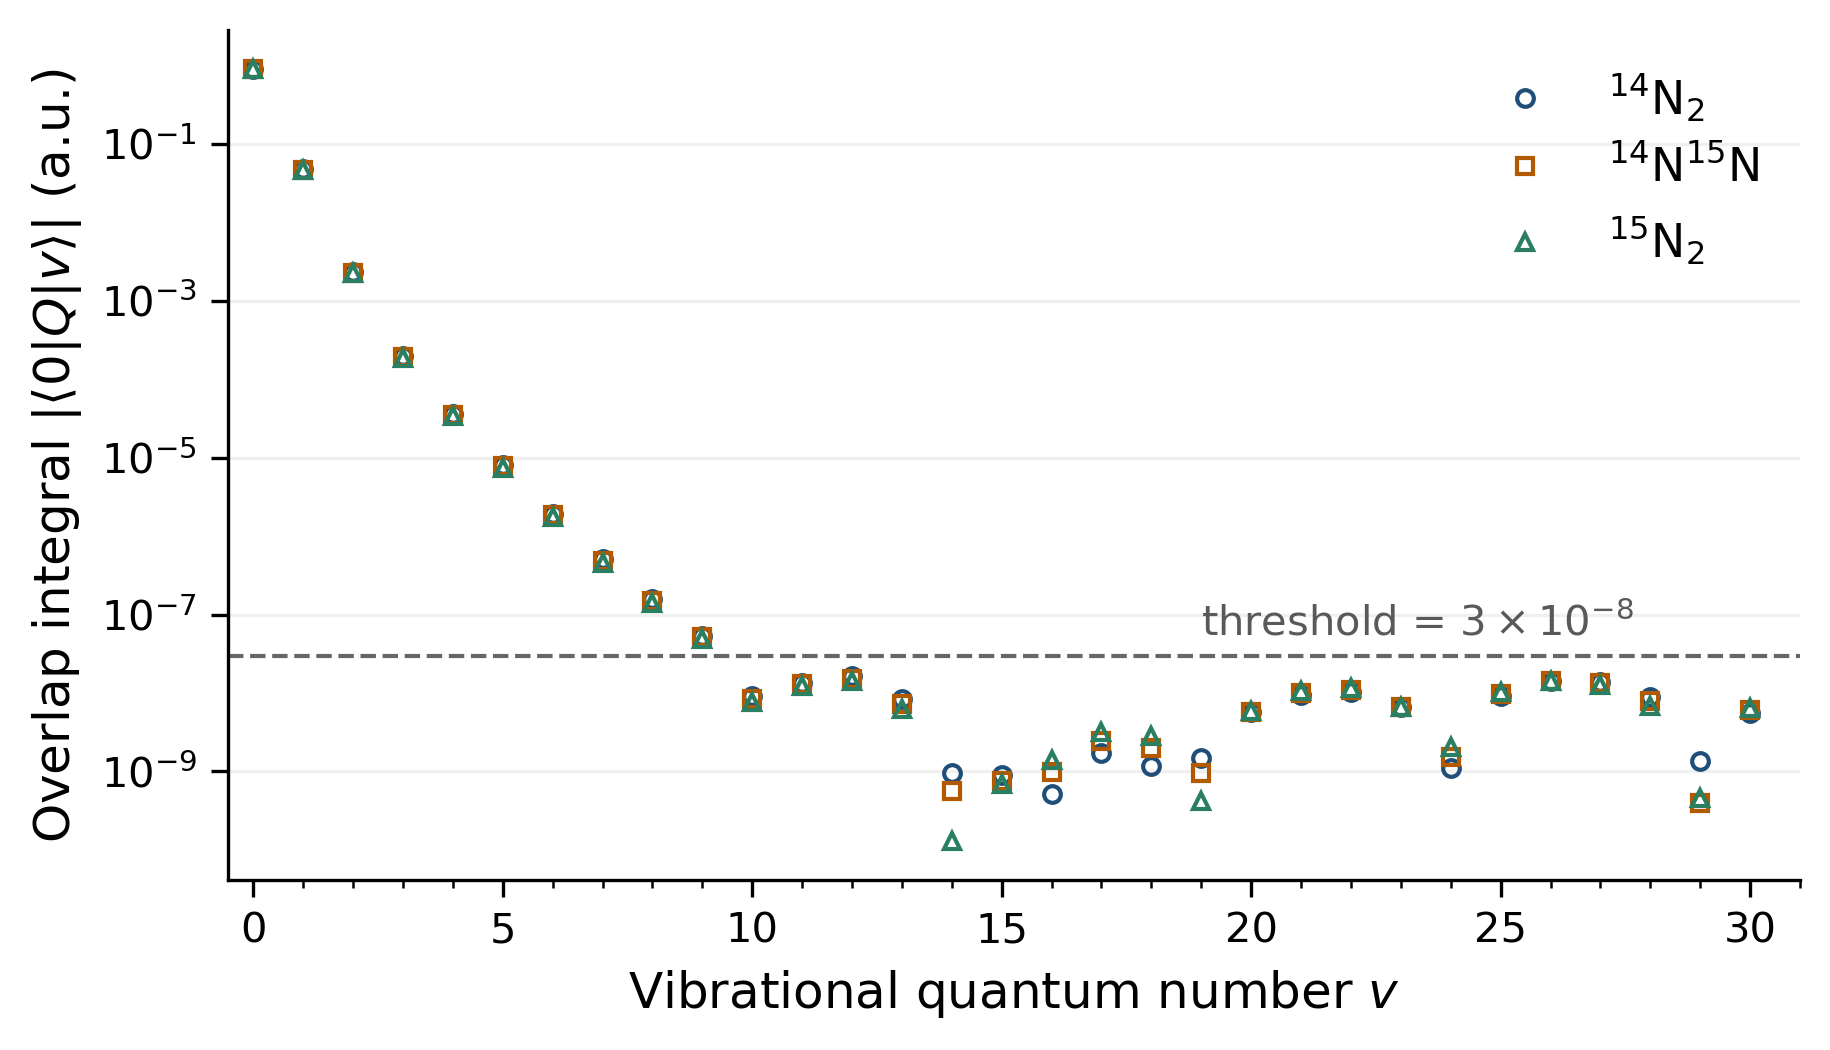

In [9]:
from matplotlib.ticker import AutoMinorLocator

fig, ax = plt.subplots(figsize=(6.2, 3.6), dpi=300)

# curves
ax.plot(v, np.abs(q_14N2),
        marker="o",
        linestyle="none",
        markersize=4,
        markerfacecolor="none",
        markeredgecolor="#1f4e79",
        label=r"$^{14}$N$_2$")

ax.plot(v, np.abs(q_14N15N),
        marker="s",
        linestyle="none",
        markersize=4,
        markerfacecolor="none",
        markeredgecolor="#b35a00",
        label=r"$^{14}$N$^{15}$N")

ax.plot(v, np.abs(q_15N2),
        marker="^",
        linestyle="none",
        markersize=4,
        markerfacecolor="none",
        markeredgecolor="#2a7f62",
        label=r"$^{15}$N$_2$")


# log scale
ax.set_yscale("log")

# labels
ax.set_xlabel(r"Vibrational quantum number $v$", fontsize=12)


ax.set_ylabel(r"Overlap integral $|\langle 0 | Q | v \rangle|$ (a.u.)", fontsize=12)


# grid (very light)
ax.grid(axis="y", which="both", color="0.94", linewidth=0.8)


# ticks
ax.tick_params(axis="both", which="major", direction="out", length=4)
ax.tick_params(axis="both", which="minor", direction="out", length=2)

ax.xaxis.set_minor_locator(AutoMinorLocator())


# axis limits
ax.set_xlim(-0.5, 31)


# remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# threshold line
threshold = 3e-8

ax.axhline(threshold,
           color="0.4",
           linestyle="--",
           linewidth=1)

# threshold label
ax.text(
    19, threshold*1.8,
    r"threshold = $3\times10^{-8}$",
    fontsize=10,
    color="0.35"
)


# legend
ax.legend(frameon=False, fontsize=11)


plt.tight_layout()
plt.show()

\caption{Absolute vibrational matrix elements $|\langle v=0|Q|v\rangle|$ of the quadrupole moment operator for the three N$_2$ isotopologues. The horizontal dashed line indicates the adopted threshold of $3\times10^{-8}$\,a.u., chosen conservatively above the numerical noise floor where the decay ceases to be smooth.}
